In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MERGED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pre_merged.csv"
)

merged = pd.read_csv(MERGED_PATH)

print("병합 데이터:", merged.shape)
print("\n컬럼:")
print(merged.columns.tolist())

merged.info()
display(merged.head())

C:\Users\leso0\AppData\Local\Temp\ipykernel_24304\2200938759.py:20: DtypeWarning: Columns (0: date) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv(MERGED_PATH)


병합 데이터: (166036, 24)

컬럼:
['code_module', 'code_presentation', 'module_presentation_length', 'id_student', 'gender', 'region', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'imd_band_cd', 'age_band_cd', 'highest_education_cd', 'id_assessment', 'assessment_type', 'date', 'weight', 'date_submitted', 'is_banked', 'score', 'date_registration', 'date_unregistration', 'unregister_yn', 'unregister_week']
<class 'pandas.DataFrame'>
RangeIndex: 166036 entries, 0 to 166035
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   code_module                 166036 non-null  str    
 1   code_presentation           166036 non-null  str    
 2   module_presentation_length  166036 non-null  int64  
 3   id_student                  166036 non-null  int64  
 4   gender                      166036 non-null  str    
 5   region                      166036 non-null  str    
 6   num

,code_module,code_presentation,module_presentation_length,id_student,gender,region,num_of_prev_attempts,studied_credits,disability,final_result,...,assessment_type,date,weight,date_submitted,is_banked,score,date_registration,date_unregistration,unregister_yn,unregister_week
0,AAA,2013J,268,11391,M,East Anglian Region,0,240,N,Pass,...,TMA,19,10.0,18,0,78.0,-159,NaN,N,N
1,AAA,2013J,268,11391,M,East Anglian Region,0,240,N,Pass,...,TMA,54,20.0,53,0,85.0,-159,NaN,N,N
2,AAA,2013J,268,11391,M,East Anglian Region,0,240,N,Pass,...,TMA,117,20.0,115,0,80.0,-159,NaN,N,N
3,AAA,2013J,268,11391,M,East Anglian Region,0,240,N,Pass,...,TMA,166,20.0,164,0,85.0,-159,NaN,N,N
4,AAA,2013J,268,11391,M,East Anglian Region,0,240,N,Pass,...,TMA,215,30.0,212,0,82.0,-159,NaN,N,N


## final_result / 수강철회 현황


,final_result,student_count
0,Pass,11827
1,Fail,5637
2,Withdrawn,4529
3,Distinction,2825


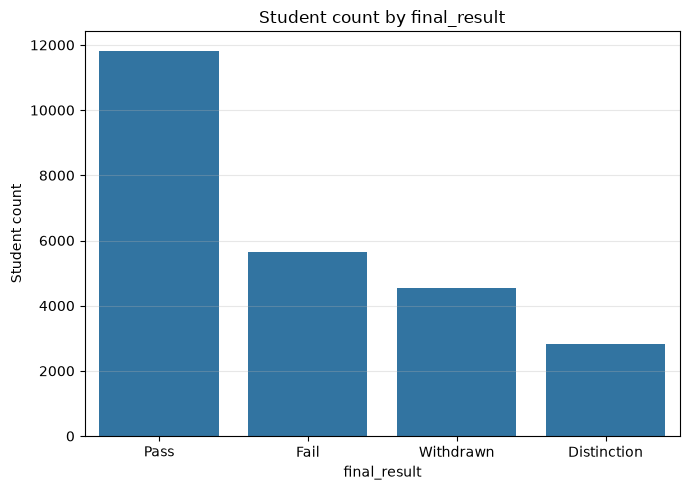

In [10]:
final_result_summary = (
    merged
    .drop_duplicates(subset=["code_module", "code_presentation", "id_student"])
    ["final_result"]
    .value_counts()
    .rename_axis("final_result")
    .reset_index(name="student_count")
)

display(final_result_summary)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=final_result_summary,
    x="final_result",
    y="student_count"
)
plt.title("Student count by final_result")
plt.xlabel("final_result")
plt.ylabel("Student count")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

unregister_yn,N,Y
final_result,,
Distinction,2825,0
Fail,5635,2
Pass,11827,0
Withdrawn,22,4507


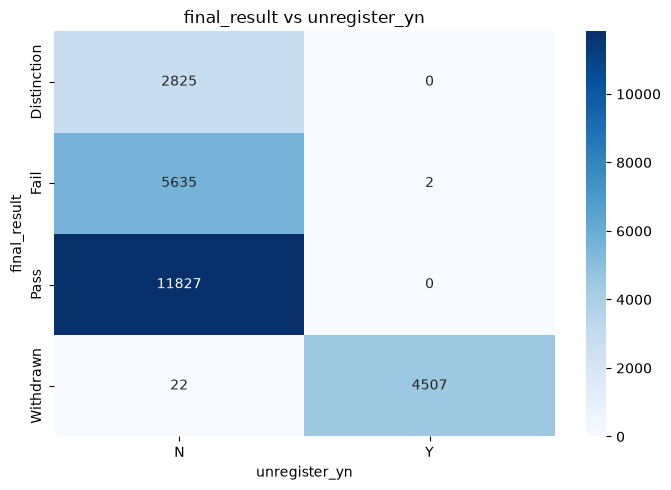

In [11]:
# final_result과 unregister_yn(파생 컬럼)이 서로 일치하는지 확인
crosstab_result = pd.crosstab(
    merged.drop_duplicates(
        subset=["code_module", "code_presentation", "id_student"]
    )["final_result"],
    merged.drop_duplicates(
        subset=["code_module", "code_presentation", "id_student"]
    )["unregister_yn"]
)

display(crosstab_result)

plt.figure(figsize=(7, 5))
sns.heatmap(
    crosstab_result,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("final_result vs unregister_yn")
plt.tight_layout()
plt.show()

## 이탈 시점(unregister_week) 분포


철회 학생 수: 4509

unregister_week 분위수:


,quantile,unregister_week
0,0.00,-7.0
1,0.25,9.0
2,0.50,16.0
3,0.75,23.0
4,0.90,29.0
5,0.95,32.0
6,1.00,64.0


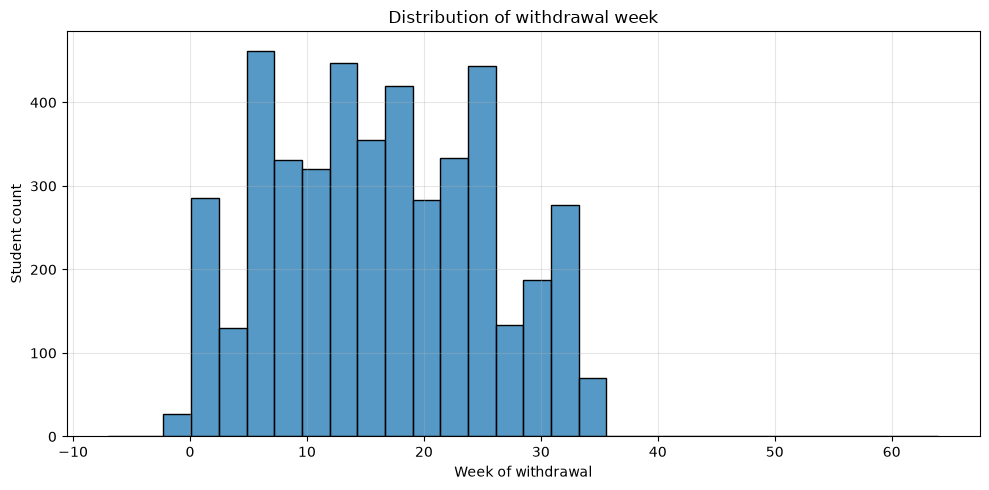

In [12]:
withdrawn_students = merged[
    merged["unregister_yn"] == "Y"
].drop_duplicates(
    subset=["code_module", "code_presentation", "id_student"]
).copy()

withdrawn_students["unregister_week_num"] = pd.to_numeric(
    withdrawn_students["unregister_week"],
    errors="coerce"
)

print("철회 학생 수:", len(withdrawn_students))
print(
    "\nunregister_week 분위수:"
)
display(
    withdrawn_students["unregister_week_num"]
    .quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0])
    .rename("unregister_week")
    .reset_index()
    .rename(columns={"index": "quantile"})
)

plt.figure(figsize=(10, 5))
sns.histplot(
    withdrawn_students["unregister_week_num"].dropna(),
    bins=30
)
plt.title("Distribution of withdrawal week")
plt.xlabel("Week of withdrawal")
plt.ylabel("Student count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 강좌(code_module)별 철회율


,code_module,student_count,withdrawn_count,withdrawal_rate
2,CCC,3190,1011,0.316928
3,DDD,4685,1089,0.232444
5,FFF,5949,1114,0.187258
1,BBB,6018,866,0.143902
0,AAA,681,91,0.133627
4,EEE,2193,232,0.105791
6,GGG,2102,106,0.050428


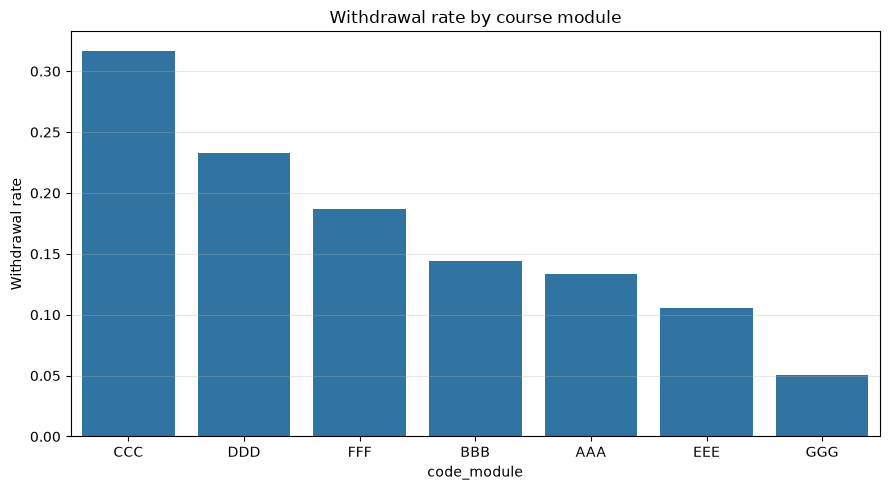

In [13]:
module_withdrawal = (
    merged
    .drop_duplicates(subset=["code_module", "code_presentation", "id_student"])
    .groupby("code_module", as_index=False)
    .agg(
        student_count=("id_student", "size"),
        withdrawn_count=("unregister_yn", lambda s: (s == "Y").sum())
    )
)

module_withdrawal["withdrawal_rate"] = (
    module_withdrawal["withdrawn_count"]
    / module_withdrawal["student_count"]
)

display(
    module_withdrawal.sort_values(
        "withdrawal_rate",
        ascending=False
    )
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=module_withdrawal.sort_values("withdrawal_rate", ascending=False),
    x="code_module",
    y="withdrawal_rate"
)
plt.title("Withdrawal rate by course module")
plt.xlabel("code_module")
plt.ylabel("Withdrawal rate")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 평가 점수(score) 분포


score 분위수:


,quantile,score
0,0.00,0.0
1,0.25,65.0
2,0.50,80.0
3,0.75,89.0
4,0.90,100.0
5,0.95,100.0
6,1.00,100.0


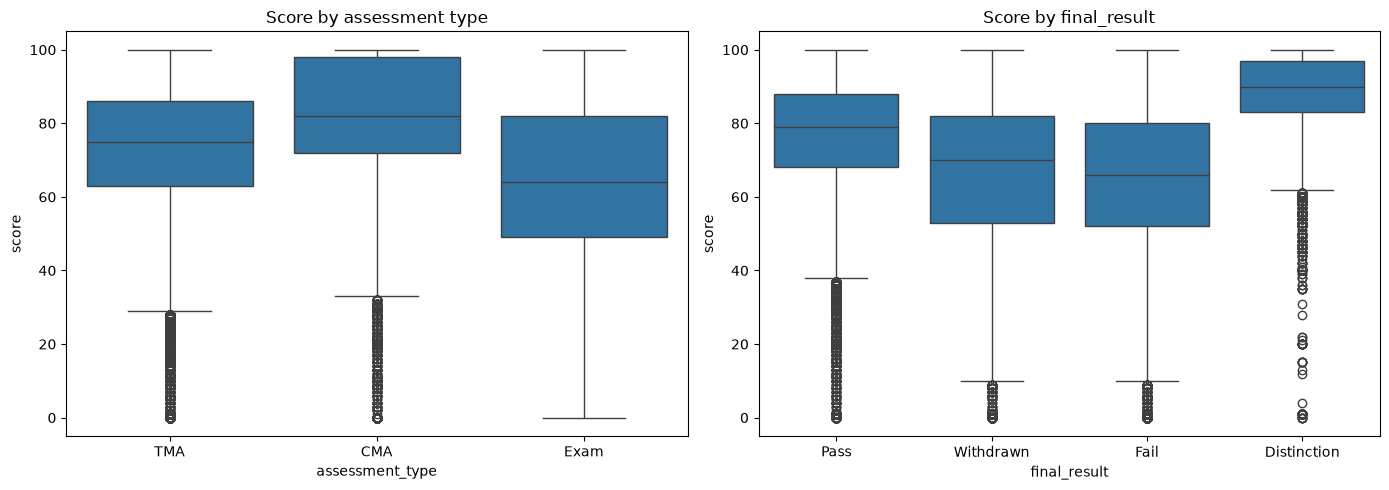

In [14]:
print("score 분위수:")
display(
    merged["score"]
    .quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0])
    .rename("score")
    .reset_index()
    .rename(columns={"index": "quantile"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=merged,
    x="assessment_type",
    y="score",
    ax=axes[0]
)
axes[0].set_title("Score by assessment type")
axes[0].set_xlabel("assessment_type")
axes[0].set_ylabel("score")

sns.boxplot(
    data=merged.drop_duplicates(
        subset=["code_module", "code_presentation", "id_student", "id_assessment"]
    ),
    x="final_result",
    y="score",
    ax=axes[1]
)
axes[1].set_title("Score by final_result")
axes[1].set_xlabel("final_result")
axes[1].set_ylabel("score")

plt.tight_layout()
plt.show()

## 제출 지연(date_submitted - date)과 성과의 관계


submission_gap 분위수 (음수 = 마감 전 제출):


,quantile,submission_gap
0,0.00,-246.0
1,0.25,-6.0
2,0.50,-1.0
3,0.75,2.0
4,0.90,5.0
5,0.95,6.0
6,1.00,372.0


,final_result,late_submission_rate
0,Distinction,0.225330
1,Fail,0.370865
2,Pass,0.259775
3,Withdrawn,0.409603


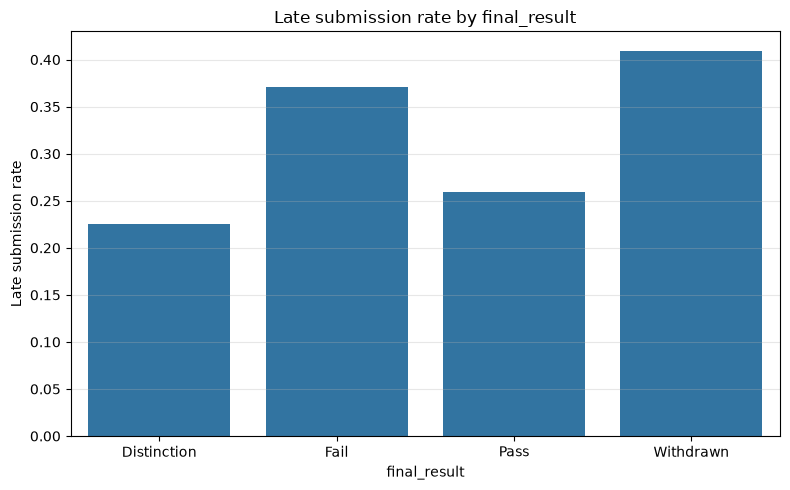

In [20]:
merged["submission_gap"] = (
    merged[merged['assessment_type']!='Exam']["date_submitted"].astype(float) - merged[merged['assessment_type']!='Exam']["date"].astype(float)
)

print("submission_gap 분위수 (음수 = 마감 전 제출):")
display(
    merged["submission_gap"]
    .quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0])
    .rename("submission_gap")
    .reset_index()
    .rename(columns={"index": "quantile"})
)

late_submission_rate = (
    merged
    .assign(is_late=lambda df: df["submission_gap"] > 0)
    .groupby("final_result", as_index=False)["is_late"]
    .mean()
    .rename(columns={"is_late": "late_submission_rate"})
)

display(late_submission_rate)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=late_submission_rate,
    x="final_result",
    y="late_submission_rate"
)
plt.title("Late submission rate by final_result")
plt.xlabel("final_result")
plt.ylabel("Late submission rate")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 인구통계 변수별 이탈/성과 비교


In [ ]:
DEMOGRAPHIC_COLUMNS = [
    "age_band_cd",
    "highest_education_cd",
    "imd_band_cd",
    "disability",
    "gender"
]

student_level = merged.drop_duplicates(
    subset=["code_module", "code_presentation", "id_student"]
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, DEMOGRAPHIC_COLUMNS):
    withdrawal_rate_by_group = (
        student_level
        .assign(is_withdrawn=lambda df: df["unregister_yn"] == "Y")
        .groupby(col, as_index=False)["is_withdrawn"]
        .mean()
        .sort_values(col)
    )

    sns.barplot(
        data=withdrawal_rate_by_group,
        x=col,
        y="is_withdrawn",
        ax=ax
    )
    ax.set_title(f"Withdrawal rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Withdrawal rate")
    ax.grid(alpha=0.3, axis="y")

# 사용하지 않는 서브플롯 숨기기
for ax in axes[len(DEMOGRAPHIC_COLUMNS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 수치형 Feature 간 상관관계


In [ ]:
NUMERIC_FEATURES = [
    "module_presentation_length",
    "weight",
    "score",
    "date_registration",
    "num_of_prev_attempts",
    "studied_credits",
    "submission_gap"
]

feature_corr = merged[NUMERIC_FEATURES].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(
    feature_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    annot_kws={"size": 8}
)
plt.title("Spearman correlation between features")
plt.tight_layout()
plt.show()

## 병합 데이터 EDA 중간 결론

아래 항목은 위 셀들을 실제로 실행한 뒤 나온 수치로 채워 넣어야 하는 자리표시자다.
(현재 환경에는 `data/processed/pre_merged.csv`가 없어 직접 실행한 결과가 아니라, 확인해야 할 항목만 정리했다.)

1. final_result 분포에서 Withdrawn 비율은 ( )% 이며, unregister_yn == 'Y'와 대체로 일치하는지/불일치하는 사례가 있는지 확인 필요.
2. unregister_week 분포상 이탈이 몰리는 구간(중앙값 __ 주차, 상위 분위수 __ 주차)이 있는지 확인하고, 있다면 이탈 골든타임 후보로 기록.
3. code_module별 철회율 차이가 (있다/없다)면, 강좌 단위로 모델을 분리할지 단일 모델에 강좌 Feature로 넣을지 결정 필요.
4. assessment_type별 score 분포 차이와, final_result별 score 분포 차이가 뚜렷한지 확인.
5. submission_gap(제출 지연)이 양수(마감 후 제출/지각)인 비율이 final_result별로 차이가 나는지 확인 — 지각 제출이 이탈의 선행 신호가 될 수 있음.
6. age_band_cd, highest_education_cd, imd_band_cd, disability, gender별 철회율 차이 중 눈에 띄는 그룹이 있는지 확인.
7. 수치형 Feature 간 상관관계에서 다중공선성이 의심되는 쌍이 있는지 확인 (예: weight와 score, studied_credits와 num_of_prev_attempts 등).
8. 현재 데이터는 학생-평가 단위(assessment level)이므로, 모델링 시 학생-강좌 단위로 집계할지 평가 단위를 그대로 쓸지 결정 필요.
